In [1]:
# ===== 기본 세트 (거의 항상 필요) =====
import pandas as pd                    # 데이터프레임 다루기 (표 형태 데이터 처리)
import numpy as np                     # 수치 계산, 배열 연산
import matplotlib.pyplot as plt        # 기본 시각화
import seaborn as sns                  # matplotlib 기반의, 더 예쁘고 간결한 통계 시각화

# ===== 파일/경로/시스템 =====
import os                              # 파일 경로 확인, 파일 존재 여부(os.path.exists) 등
from pathlib import Path               # 폴더/파일 경로를 객체로 다루기 (work_dir / "파일명")
import joblib                          # 학습된 scaler/encoder를 파일로 저장하고 재사용
import platform                        # OS 종류 확인 (Windows/Mac/Linux 구분 필요할 때)
import warnings                        # 경고 메시지 제어(숨기기/표시)

# ===== 벤치마크/성능 측정 =====
import time                            # 코드 실행 시간 측정 (time.perf_counter())
import psutil                          # 메모리 사용량 측정 (rss_mb 등)
import gc                              # 메모리 강제 정리(garbage collection)

# ===== 결측치 탐색 시각화 =====
import missingno as msno               # 결측치 위치(matrix), 관계(heatmap) 시각화

# ===== 인터랙티브 시각화 =====
import plotly.express as px            # 마우스 hover/zoom 가능한 인터랙티브 그래프
import plotly.io as pio                 # plotly 렌더러(출력 방식) 설정

# ===== 대용량 데이터 처리 =====
import polars as pl                     # pandas보다 빠른 대용량 데이터 처리 (Rust 기반)

# ===== 통계 검증 =====
import statsmodels.api as sm            # 회귀분석, 다중공선성(Cond. No.) 등 통계 검증
from scipy import stats

# ===== 한글 폰트 설정 =====
import matplotlib.font_manager as fm    # 그래프에 한글 폰트 적용 시 필요
import matplotlib.pyplot as plt

font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

# ===== 인코딩/스케일링/모델링 (sklearn) =====
from sklearn.preprocessing import LabelEncoder      # 카테고리를 숫자로 변환 (순서형)
from sklearn.preprocessing import MinMaxScaler       # 0~1 범위로 스케일링
from sklearn.preprocessing import StandardScaler     # 평균0, 표준편차1로 스케일링
from sklearn.preprocessing import RobustScaler       # 이상치에 강한 스케일링 (median/IQR 기반)
from sklearn.linear_model import LinearRegression    # 선형 회귀 모델
from sklearn.linear_model import LogisticRegression  # 로지스틱 회귀(분류) 모델
from sklearn.ensemble import RandomForestRegressor   # 랜덤포레스트(트리 기반) 모델
from sklearn.metrics import roc_auc_score, log_loss  # 분류 모델 평가지표

In [2]:
# 문제 1 · 데이터 준비 — 실행만 하세요
penguins = sns.load_dataset('penguins')

print("데이터 크기:", penguins.shape)
print("\n종별 개체 수:")
print(penguins['species'].value_counts())
print("\n결측치 개수:")
print(penguins.isna().sum())

penguins.head()

데이터 크기: (344, 7)

종별 개체 수:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

결측치 개수:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


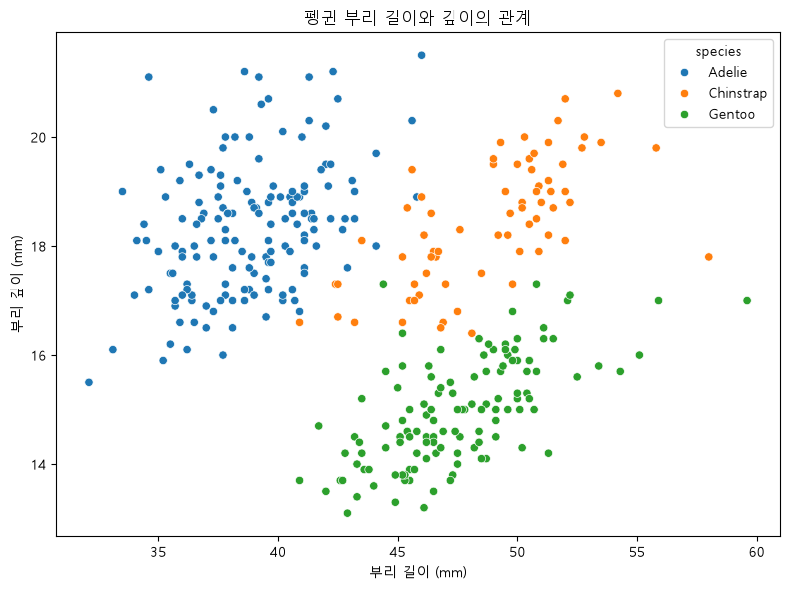

In [6]:
penguins = sns.load_dataset('penguins')

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", ax=ax)

ax.set_title("펭귄 부리 길이와 깊이의 관계")
ax.set_xlabel("부리 길이 (mm)")
ax.set_ylabel("부리 깊이 (mm)")
plt.tight_layout()
plt.show()

In [4]:
# 1. 전체 데이터 기준 상관계수
overall_corr = penguins["bill_length_mm"].corr(penguins["bill_depth_mm"])
print(f"전체 상관계수: {overall_corr:.3f}")

# 2. 종별 상관계수
print("\n종별 상관계수:")
species_corr = penguins.groupby("species").apply(
    lambda x: x["bill_length_mm"].corr(x["bill_depth_mm"])
)
print(species_corr)

# 3. 부호 비교
print(f"\n전체 상관계수 부호: {'양수' if overall_corr > 0 else '음수'}")
for species, corr in species_corr.items():
    print(f"{species} 상관계수 부호: {'양수' if corr > 0 else '음수'}")

전체 상관계수: -0.235

종별 상관계수:
species
Adelie       0.391492
Chinstrap    0.653536
Gentoo       0.643384
dtype: float64

전체 상관계수 부호: 음수
Adelie 상관계수 부호: 양수
Chinstrap 상관계수 부호: 양수
Gentoo 상관계수 부호: 양수


💬 정리 · 결과를 말로 설명해 보기
Q1의 산점도에서 두 변수는 어떤 방향의 관계로 보였나요? Q3의 전체 상관계수와 부호가 일치하나요?
▸ x가 클수록 y가 작아지는 음의 상관관계로 보임, Q3의 전체 상관계수 역시 -0.235로 음의 상관계수로 확인됨.

Q3의 종별 상관계수는 전체와 부호가 같나요, 다른가요?
▸ 종별 상관계수는 양의 상관계수로 확인되어 전체와는 다르게 확인됨.

같은 데이터인데 전체와 집단별 결론이 정반대로 나온 이유를 설명해 보세요. 무엇이 이 착시를 만들고 있나요?
▸ 각 종별로 펭귄들의 특징이 있다 Gentoo의 부리 길이가 긴편에 속하지만 깊이는 길이에 깊지는 않다.
Chinstrap는 Gentoo와 부리 길이는 비슷하지만 깊이는 훨씬 깊은 편에 속한다.
Adelie는 부리 길이는 짧지만 깊이는 다른 두 종에 비해서 깊은 편에 속한다.
이러한 데이터를 종을 구분하지 않고 전체로 산점도를 보았을 땐 그 경향이 우하향하는 착시를 보일 수 있다.

만약 이 데이터에 '종' 정보가 없었다면 우리는 어떤 잘못된 결론을 내렸을까요?
▸ 펭귄의 부리가 길면 깊이가 작아질 수 있다는 잘못된 결론을 내리게 된다.

결측치 제거 전: 344 행
결측치 제거 후: 342 행


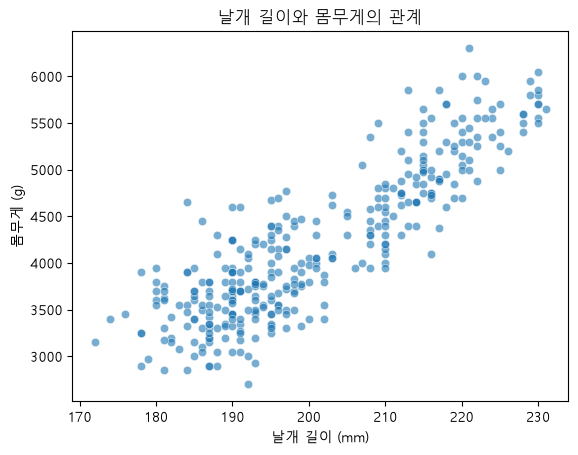

In [ ]:
# 문제 2 · 데이터 준비 — 실행만 하세요
df_corr = penguins[['flipper_length_mm', 'body_mass_g']].dropna()

print("결측치 제거 전:", len(penguins), "행")
print("결측치 제거 후:", len(df_corr), "행")

# 두 변수의 관계를 그림으로 먼저 확인 (문제 1의 교훈!)
sns.scatterplot(data=df_corr, x='flipper_length_mm', y='body_mass_g', alpha=0.6)
plt.title("날개 길이와 몸무게의 관계")
plt.xlabel("날개 길이 (mm)")
plt.ylabel("몸무게 (g)")
plt.show()

In [8]:
alpha = 0.05

for col in ["flipper_length_mm", "body_mass_g"]:
    data = penguins[col].dropna()   # 결측치 제거 (Shapiro 검정은 결측치 허용 안 함)
    stat, p_value = stats.shapiro(data)
    
    print(f"=== {col} ===")
    print(f"통계량: {stat:.4f}, p-값: {p_value:.4f}")
    
    if p_value < alpha:
        print(f"→ p-value({p_value:.4f}) < {alpha}: 정규성을 기각합니다 (정규분포를 따르지 않음)")
    else:
        print(f"→ p-value({p_value:.4f}) >= {alpha}: 정규성을 기각할 수 없습니다 (정규분포를 따른다고 볼 수 있음)")
    print()

=== flipper_length_mm ===
통계량: 0.9515, p-값: 0.0000
→ p-value(0.0000) < 0.05: 정규성을 기각합니다 (정규분포를 따르지 않음)

=== body_mass_g ===
통계량: 0.9592, p-값: 0.0000
→ p-value(0.0000) < 0.05: 정규성을 기각합니다 (정규분포를 따르지 않음)



In [10]:
from scipy import stats

r, p_value = stats.pearsonr(df_corr["flipper_length_mm"], df_corr["body_mass_g"])

print(f"상관계수(r): {r:.4f}")
print(f"p-값: {p_value:.4f}")

상관계수(r): 0.8712
p-값: 0.0000


In [12]:
from scipy import stats

rho, p_value_spearman = stats.spearmanr(df_corr["flipper_length_mm"], df_corr["body_mass_g"])

print(f"스피어만 상관계수(ρ): {rho:.4f}")
print(f"p-값: {p_value_spearman:.4f}")

스피어만 상관계수(ρ): 0.8400
p-값: 0.0000


In [ ]:
# 문제 2 · Q4
# 정규성 검정 결과 (피어슨의 전제가 지켜졌나요?): 두 변수 모두 p < 0.05에 해당 정규분포를 따르지 않아 전제가 지켜지지 않았음.
# 피어슨 r 값과 p-값: r = 0.8712, p-값 = 0.0000 / r 값이 양의 상관계수에 해당하고 p-값이 0.05 미만으로 날개의 길이와 몸무게의 상관관계가 유의미하다는 결과를 보여줌.
# 스피어만 ρ 값: 0.0000
# 부호(+/-)가 뜻하는 관계의 방향: -의 경우 날개의 길이가 커질수록 몸무게가 작아진다는 의미를 가지고 +의 경우 날개의 길이가 커질수록 몸무게가 커진다는 의미를 가짐.
# 절대값의 크기가 뜻하는 관계의 강도: 피어슨 0.8712, 스피어만 0.8400으로 절대값 1에 가깝기 때문에 관계의 강도가 강하다는 것을 의미함.

💬 정리 · 결과를 말로 설명해 보기
### Q1에서 정규성이 기각되었습니다. 그렇다면 피어슨 상관계수를 쓰면 안 되는 걸까요? Q2와 Q3의 값을 비교해서 판단해 보세요.
▸ 정규성이 기각된다면 피어슨 상관계수의 사용 시 주의가 필요하다는 의미입니다.
하지만 정규성이 기각되었음에도 표본의 크기가 충분히 크기 때문에 스피어만 상관계수와 비교하여 Q2(피어슨 r=0.8712)와 Q3(스피어만 ρ=0.8400)에 대한 결과를 얻었고 두 값의 차이가 0.03밖에 안 될 정도로 매우 비슷하여 '피어슨 상관계수가 크게 왜곡되지 않았다'라는 정보를 얻을 수 있습니다.

정규성 기각이 피어슨 상관계수를 절대 쓰면 안 된다는 의미는 아니고, 순위 기반의 스피어만 상관계수와 비교해서 결과가 크게 다르지 않다면 피어슨 상관계수의 결과도 참고할 만하다고 판단할 수 있습니다.

### 피어슨과 스피어만이 비슷하게 나왔다는 것은 무엇을 뜻할까요? 만약 두 값이 크게 달랐다면 어떤 상황을 의심해야 할까요?
▸ 피어슨과 스피어만의 결과가 비슷하게 나온 것은 두 변수간의 이상지나 비선형적인 패턴에 크게 영향이 없는 선형적인 관계를 가지는 것을 의미합니다.
만약 두 값이 크게 다르게 확인되었다면 이상치가 존재하여 피어슨의 값을 크게 왜곡하였거나 두 변수간의 관계가 선형이 아닌 비선형의 관계를 의미합니다.

### Q2의 p-값은 무엇에 대한 검정인가요? "상관계수가 크다"와 "상관계수가 유의하다"는 같은 말인가요?
▸ Q2의 P-값은 피어슨 상관계수 r 값에 대한 검정입니다.
(피어슨 상관계수 r(0.87)에 대한 p-value 입니다.)

상관계수가 크다와 유의하다는 같은 의미를 가지지 않고 상관계수가 큰 것은 실질적으로 관계의 강도가 얼마나 강한지를 의미하고 있고
유의하다는 관계의 강도가 나타난 현상이 발생할 수 있는 확률로 통계적으로 이 관계가 얼마나 우연이 아닌지를 의미하고 있습니다.

### '날개가 길어지는 것이 몸무게를 무겁게 만드는 원인이다'라고 결론 내릴 수 있을까요? 교란변수 / 역인과 / 우연 세 가지로 나누어 설명해 보세요.
▸ 상관관계만으로 인과관계를 내리는 것은 대표적인 오류에 해당하며, 인과관계에 대한 결론을 내리면 안됩니다.

교란변수(confounder): 날개의 길이와 몸무게 이외의 숨은 원인(펭귄의 종, 성별 등)을 바탕으로 날개와 몸무게에 영향을 줄 수 있습니다.

역인과(reverse causation): x와 y를 반대하는 개념으로 몸무게가 큰 개체들이 날개가 길어지는 경향을 보일 수 있음을 생각해야합니다.

우연(coincidence): 우연의 경우 우리가 추출한 표본에서 우연히 상관관계가 있다고 보여질 수 있지만 실제 모집단에서는 정 반대의 결과를 가질수도 있다는 의미를 가지고 있지만,
우리가 확인한 피어슨, 스피어만의 r값과 p값을 기준으로 한다면 단순 우연으로 보기는 어렵다는 결론을 내릴 수 있습니다.

In [13]:
# 문제 3 · 데이터 준비 — 실행만 하세요
penguins_cleaned = penguins.dropna(subset=['body_mass_g', 'flipper_length_mm'])

print("분석에 사용할 데이터:", len(penguins_cleaned), "행")
print("문제 2의 df_corr과 동일한가?:", len(penguins_cleaned) == len(df_corr))

분석에 사용할 데이터: 342 행
문제 2의 df_corr과 동일한가?: True


In [23]:
X = df_corr["flipper_length_mm"]
y = df_corr["body_mass_g"]

X = sm.add_constant(X)   # 절편(intercept) 추가

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Wed, 29 Jul 2026   Prob (F-statistic):          4.37e-107
Time:                        14:20:43   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -5780.8314    305.81

In [17]:
X = df_corr["body_mass_g"]
y = df_corr["flipper_length_mm"]

X = sm.add_constant(X)   # 절편(intercept) 추가

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      flipper_length_mm   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Wed, 29 Jul 2026   Prob (F-statistic):          4.37e-107
Time:                        14:13:38   Log-Likelihood:                -1145.5
No. Observations:                 342   AIC:                             2295.
Df Residuals:                     340   BIC:                             2303.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         136.7296      1.997     68.473      

In [ ]:
# 문제 3 · Q3
# 절편(a) 값: -5780.8314
# 기울기(b) 값: 49.6856
# 완성된 회귀식 → 몸무게(g) = -5780.8314 + 49.6856 × 날개길이(mm)

In [15]:
slope = model.params["flipper_length_mm"]

weight_increase = slope * 10

print(f"날개 길이가 평균보다 10mm 더 길면, 몸무게는 약 {weight_increase:.2f}g 더 무겁습니다.")

날개 길이가 평균보다 10mm 더 길면, 몸무게는 약 496.86g 더 무겁습니다.


In [16]:
std_x = df_corr["flipper_length_mm"].std()
std_y = df_corr["body_mass_g"].std()

# ① 기울기 = r × (y의 표준편차 / x의 표준편차)
slope_left = model.params["flipper_length_mm"]           # 좌변: 실제 회귀모델의 기울기
slope_right = r * (std_y / std_x)                          # 우변: 공식으로 계산한 값

print("=== ① 기울기 공식 확인 ===")
print(f"좌변(모델의 기울기): {slope_left:.4f}")
print(f"우변(r × std_y/std_x): {slope_right:.4f}")
print(f"일치 여부: {np.isclose(slope_left, slope_right)}")

print()

# ② R² = r²
r_squared_left = model.rsquared      # 좌변: 모델의 R²
r_squared_right = r ** 2              # 우변: r을 제곱한 값

print("=== ② R² = r² 공식 확인 ===")
print(f"좌변(모델의 R²): {r_squared_left:.4f}")
print(f"우변(r²): {r_squared_right:.4f}")
print(f"일치 여부: {np.isclose(r_squared_left, r_squared_right)}")

=== ① 기울기 공식 확인 ===
좌변(모델의 기울기): 49.6856
우변(r × std_y/std_x): 49.6856
일치 여부: True

=== ② R² = r² 공식 확인 ===
좌변(모델의 R²): 0.7590
우변(r²): 0.7590
일치 여부: True


💬 정리 · 결과를 말로 설명해 보기
### 기울기(b) 값을 "날개 길이가 ○○할 때 몸무게가 ○○한다"는 문장으로 풀어 써 보세요.
▸ 날개 길이가 평균보다 10mm 더 길면, 몸무게는 약 496.86g 더 무겁습니다.

### 절편(a)이 음수로 나왔습니다. 이 숫자를 "날개 길이가 0mm인 펭귄의 몸무게"로 해석해도 될까요? 왜 그럴까요?
▸ 절편의 경우 x, y 날개의 길이와 몸무게가 만나는 직선을 수학적으로 정의한 값이기 때문에 실제 데이터에서 날개의 길이가 0mm는 존재할 수 없고 뭄무게 또한 -5780이라는 음수는 존재할 수 없는 값에 해당하여 해석에 주의해야 합니다.

### Q5에서 R² = r²을 확인했습니다. 그렇다면 설명변수와 반응변수를 서로 바꿔 분석하면 기울기와 R²는 각각 같을까요, 다를까요?
▸ R²는 완전히 같지만(0.759로 동일), 기울기는 완전히 다릅니다(49.6856 vs 0.0153).

R²가 같은 이유: R² = r²인데, 상관계수 r은 "x와 y의 관계"나 "y와 x의 관계"나 방향에 상관없이 항상 같은 값이기 때문입니다 (대칭적인 값).

기울기가 다른 이유: 기울기 = r × (y의 표준편차 / x의 표준편차)인데, 방향을 바꾸면 "분자"와 "분모"에 들어가는 표준편차가 서로 뒤바뀌기 때문입니다. 게다가 단위 자체도 바뀝니다 — 원래는 "mm당 g"이었는데, 뒤집으면 "g당 mm"가 되어서, 숫자의 크기 자체도 완전히 달라지는 것이 당연합니다.

### 상관계수 r은 단위 없는 −1~1 값이고, 기울기 b는 'mm당 g'이라는 단위를 가집니다. 회귀가 상관보다 더 알려주는 것은 무엇인가요?
▸ 상관계수는 "두 변수가 얼마나 강하게, 어느 방향으로 관련되어 있는지"라는 "단위 없는 강도"만 알려주는 반면, 회귀의 기울기는 "실제 단위를 가진, 구체적인 예측 공식"까지 제공합니다.

상관계수만 알면: "날개 길이와 몸무게는 강하게(0.87) 관련이 있다"는 것만 알 수 있고, "그래서 정확히 몇 g이 늘어나는지"는 알 수 없습니다.
회귀(기울기)까지 알면: **"날개 길이가 1mm 늘어나면, 몸무게가 정확히 49.69g 늘어난다"**는 구체적인 수치와 방향을 알 수 있고, 이를 이용해 특정 날개 길이를 가진 펭귄의 몸무게를 실제로 예측할 수 있습니다.

한마디로, 상관계수는 "관계가 있다/없다, 강하다/약하다"를 말해주고, 회귀는 거기서 한 발 더 나아가 "그래서 구체적으로 얼마나, 어떻게 변하는지"까지 계산 가능한 도구를 제공합니다.

In [25]:
print("분석 대상 데이터:", len(penguins_cleaned), "행 (문제 3과 동일)")
print("설명변수: flipper_length_mm  /  반응변수: body_mass_g")

분석 대상 데이터: 342 행 (문제 3과 동일)
설명변수: flipper_length_mm  /  반응변수: body_mass_g


In [ ]:
# 문제 4 · Q1
# H₀ (귀무가설): 펭귄의 날개 길이와 몸무게는 관계가 없다.
# H₁ (대립가설): 펭귄의 날개 길이와 몸무게는 관계가 있다.

In [36]:
p_value_slope = model.pvalues["flipper_length_mm"]
print(f"flipper_length_mm의 P>|t|: {p_value_slope}")

flipper_length_mm의 P>|t|: 4.37068096300007e-107


In [37]:
alpha = 0.05
p_value_slope = model.pvalues["flipper_length_mm"]

if p_value_slope < alpha:
    print(f"p-value({p_value_slope:.4e}) < 유의수준({alpha})")
    print("→ 귀무가설을 기각한다. 날개 길이는 몸무게에 통계적으로 유의한 영향을 미친다.")
else:
    print(f"p-value({p_value_slope:.4e}) >= 유의수준({alpha})")
    print("→ 귀무가설을 기각하지 못한다. 날개 길이가 몸무게에 유의한 영향을 미친다고 볼 수 없다.")

p-value(4.3707e-107) < 유의수준(0.05)
→ 귀무가설을 기각한다. 날개 길이는 몸무게에 통계적으로 유의한 영향을 미친다.


In [27]:
n = len(df_corr)

t_manual = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
t_model = model.tvalues["flipper_length_mm"]

print(f"공식으로 직접 계산한 t-통계량: {t_manual:.4f}")
print(f"model.tvalues에서 가져온 t-통계량: {t_model:.4f}")
print(f"일치 여부: {np.isclose(t_manual, t_model)}")

공식으로 직접 계산한 t-통계량: 32.7222
model.tvalues에서 가져온 t-통계량: 32.7222
일치 여부: True


In [28]:
# Adelie 종, 수컷만 필터링
adelie_male = penguins[(penguins["species"] == "Adelie") & (penguins["sex"] == "Male")]
adelie_male = adelie_male[["bill_length_mm", "body_mass_g"]].dropna()

X = sm.add_constant(adelie_male["bill_length_mm"])
y = adelie_male["body_mass_g"]
model_adelie = sm.OLS(y, X).fit()

n = len(adelie_male)
r_squared = model_adelie.rsquared
p_value_slope = model_adelie.pvalues["bill_length_mm"]

print(f"표본 크기(n): {n}")
print(f"R²: {r_squared:.4f}")
print(f"기울기의 p-값: {p_value_slope:.4f}")

alpha = 0.05
if p_value_slope < alpha:
    print(f"→ p-value({p_value_slope:.4f}) < {alpha}: 귀무가설을 기각한다. 부리 길이는 몸무게에 유의한 영향을 미친다.")
else:
    print(f"→ p-value({p_value_slope:.4f}) >= {alpha}: 귀무가설을 기각하지 못한다.")

표본 크기(n): 73
R²: 0.0486
기울기의 p-값: 0.0610
→ p-value(0.0610) >= 0.05: 귀무가설을 기각하지 못한다.


💬 정리 · 결과를 말로 설명해 보기
p-값이 작다는 것은 정확히 무엇이 작다는 뜻인가요? "귀무가설이 참일 확률"이라고 말해도 될까요?
▸ P-값 0.05보다 작다는 것은 귀무가설 펭귄의 날개 길이와 몸무게와의 관련은 없다.라는 가설에서 우리가 관찰한 정도로 강한 상관관계(또는 그보다 더 극단적인 결과)가 나올 확률
즉, 귀무가설을 기각하고 대립가설을 지지한다.

Q4에서 두 t값이 일치했습니다. 이것은 상관계수의 검정과 회귀계수의 검정이 어떤 관계임을 뜻하나요?
▸ 상관계수 검정 결과와 회귀계수 검정 결과가 동일하다는 의미를 지닌다.

Q5의 결과는 Q2와 어떻게 달랐나요? 같은 penguins 데이터인데 결론이 갈린 이유를 표본 크기와 관계의 강도(R²) 두 측면에서 설명해 보세요.
▸ Q5의 결과 R2는 0.048, P-값은 0.061로 귀무가설을 기각하지 못하는 결론이 나왔다.
Q5의 경우 Adelie 종 그중에서도 수컷의 표본을 선택하여 표본의 수가 342에서 73으로 줄어들어 결론이 다르게 나왔을 수 있다.

Q5처럼 p-값이 0.05보다 조금 큰 경우, "두 변수는 관계가 없음이 증명되었다"고 말할 수 있을까요? 어떻게 말하는 것이 정확할까요?
▸ 전체 펭귄의 날개 길이와 몸무게는 관계가 있지만, 그 중에서 Adelie, 수컷의 경우엔 날개 길이와 뭄무게가 관계가 없다는 귀무가설을 기각할 수 없다.

In [29]:
print("분석 대상 데이터:", len(penguins_cleaned), "행")
print("모형: body_mass_g ~ flipper_length_mm")

분석 대상 데이터: 342 행
모형: body_mass_g ~ flipper_length_mm


In [ ]:
# 문제 5 · Q1
# R-squared 값: 0.0486
# 설명력 해석 (몸무게 변동의 몇 %를 설명하나요?): Adelie 종 그중에서 수컷의 경우 부리 길이(bill_length_mm)는 몸무게(body_mass_g) 변동의 약 4.86%만을 설명한다.
# 나머지 약 95.14%는 부리 길이가 아닌 다른 요인(개체 차이, 측정 오차, 기타 변수 등)에 의한 것이다.


r_squared = model_adelie.rsquared
print(f"R-squared: {r_squared:.4f}")
print(f"R-squared(%): {r_squared * 100:.2f}%")

R-squared: 0.0486
R-squared(%): 4.86%


In [31]:
predicted = model_adelie.fittedvalues   # 예측값
residuals = model_adelie.resid           # 잔차 (실제값 - 예측값)

print(f"잔차 개수: {len(residuals)}")
print(f"잔차 평균: {residuals.mean():.10f}")

잔차 개수: 73
잔차 평균: -0.0000000000


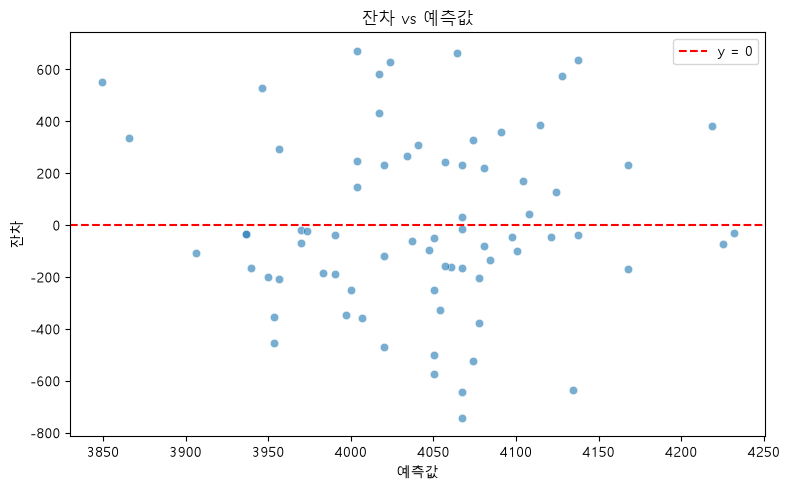

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=predicted, y=residuals, alpha=0.6, ax=ax)

ax.axhline(y=0, color="red", linestyle="--", label="y = 0")

ax.set_title("잔차 vs 예측값")
ax.set_xlabel("예측값")
ax.set_ylabel("잔차")
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_stat, bp_p_value, f_stat, f_p_value = het_breuschpagan(model_adelie.resid, model_adelie.model.exog)

print(f"브루쉬-페이건 통계량: {bp_stat:.4f}")
print(f"p-값: {bp_p_value:.4f}")

alpha = 0.05
if bp_p_value < alpha:
    print(f"→ p-value({bp_p_value:.4f}) < {alpha}: 귀무가설을 기각한다. 이분산성이 의심된다.")
else:
    print(f"→ p-value({bp_p_value:.4f}) >= {alpha}: 귀무가설을 기각하지 못한다. 등분산성 가정에 문제가 없다고 볼 수 있다.")

브루쉬-페이건 통계량: 0.0003
p-값: 0.9865
→ p-value(0.9865) >= 0.05: 귀무가설을 기각하지 못한다. 등분산성 가정에 문제가 없다고 볼 수 있다.


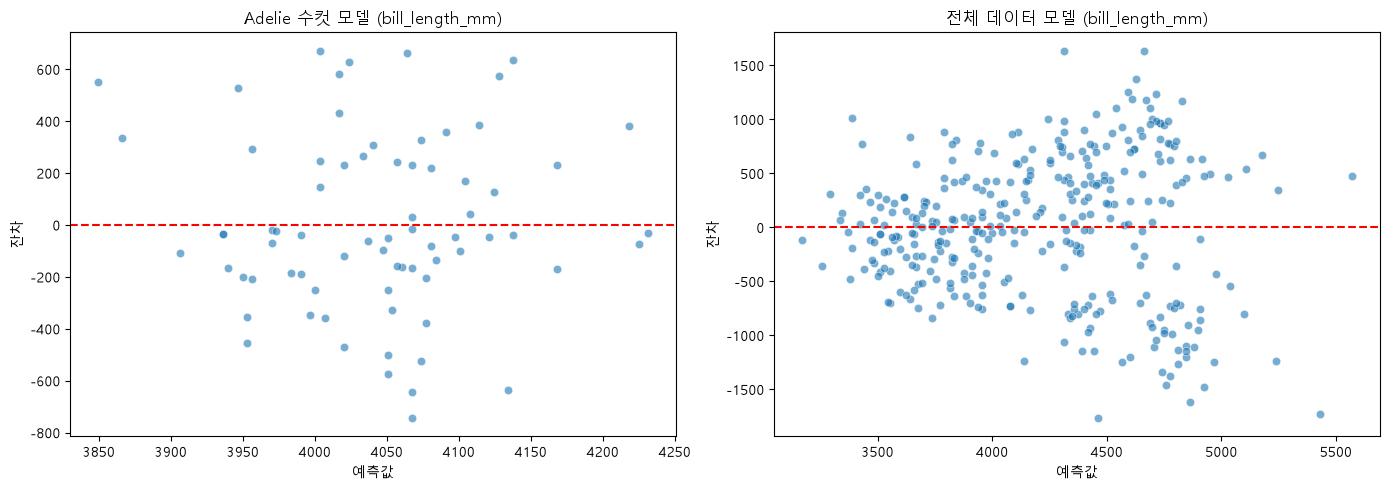

Adelie 수컷 모델의 BP p-값: 0.9865
전체 데이터 모델의 BP p-값: 0.0000


In [34]:
# 1. 비교군: 전체 데이터로 모델 적합
df_bill = penguins[["bill_length_mm", "body_mass_g"]].dropna()
X_bill = sm.add_constant(df_bill["bill_length_mm"])
y_bill = df_bill["body_mass_g"]
model_bill = sm.OLS(y_bill, X_bill).fit()

# 2. 두 모형의 잔차 산점도를 나란히
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=model_adelie.fittedvalues, y=model_adelie.resid, alpha=0.6, ax=axes[0])
axes[0].axhline(y=0, color="red", linestyle="--")
axes[0].set_title("Adelie 수컷 모델 (bill_length_mm)")
axes[0].set_xlabel("예측값")
axes[0].set_ylabel("잔차")

sns.scatterplot(x=model_bill.fittedvalues, y=model_bill.resid, alpha=0.6, ax=axes[1])
axes[1].axhline(y=0, color="red", linestyle="--")
axes[1].set_title("전체 데이터 모델 (bill_length_mm)")
axes[1].set_xlabel("예측값")
axes[1].set_ylabel("잔차")

plt.tight_layout()
plt.show()

# 3. 브루쉬-페이건 p-값 비교
bp_adelie = het_breuschpagan(model_adelie.resid, model_adelie.model.exog)[1]
bp_bill = het_breuschpagan(model_bill.resid, model_bill.model.exog)[1]

print(f"Adelie 수컷 모델의 BP p-값: {bp_adelie:.4f}")
print(f"전체 데이터 모델의 BP p-값: {bp_bill:.4f}")

In [35]:
predicted = model_bill.fittedvalues   # 예측값
residuals = model_bill.resid           # 잔차 (실제값 - 예측값)

print(f"잔차 개수: {len(residuals)}")
print(f"잔차 평균: {residuals.mean():.10f}")

잔차 개수: 342
잔차 평균: -0.0000000000


부리 길이(bill_length_mm)는 몸무게(body_mass_g)에 통계적으로 유의한 정(+)의 영향을 미쳐(β=87.42g/mm, p<0.001) 몸무게 변동의 약 35.4%(R²=0.354)를 설명하지만, 브루쉬-페이건 검정 결과 이분산성이 확인되어(p<0.001) 이는 종(species) 간 이질성이 혼재된 결과일 가능성이 높으므로 해석에 주의가 필요하다.

왜 "주의가 필요하다"는 표현이 중요할까요

단순히 "유의하고 설명력도 있다"고만 쓰면, 앞서 발견한 중요한 문제(이분산성, 종에 의한 교란)를 숨기는 것이 됩니다. 좋은 보고서는 "좋은 결과"만 강조하는 게 아니라, "이 결과를 얼마나 신뢰할 수 있는지"에 대한 한계까지 정직하게 명시해야 합니다. 오늘 하루 종일 확인하신 것처럼, "전체 데이터를 그대로 쓰는 것"보다 "종을 나눠서 보는 것"이 더 정확한 분석이 될 수 있다는 시사점도 이 문장에 함축되어 있습니다.

💬 정리 · 결과를 말로 설명해 보기
Q3·Q4에서 우리 모형의 잔차는 어떤 상태였나요? 이 결과를 근거로 문제 3·4의 해석을 신뢰할 수 있을까요?
▸ 잔차는 실제값과 예측값의 차이(오차)로 우리 모형에서는 산점이 불규칙하게 보이는 즉 등분산성이 확인되어 문제 3, 4의 결과를 신뢰 할 수 있다.

Q5의 두 잔차 산점도는 어떻게 달랐나요? 비교군에서 관찰된 모양을 강의에서 배운 용어로 무엇이라 부르나요?
▸ Adelie 수컷 모델의 경우 산점도가 고르게 분포되어 등분산성을 모두 확인할 수 있는데 전체 데이터에선 왼쪽이 좁고 오른쪽으로 넓어지는 깔때기 모양으로 등분산성이 아닌 이분산성으로 보인다.

비교군처럼 등분산성이 깨졌을 때, 잘못된 것은 기울기 값 자체인가요, 아니면 그 값의 통계적 해석인가요?
▸ 값의 통계적 해석을 날개와 몸무게간의 관련이 다른 종, 성별 등의 변수로 인하여 영향이 있을 수 있다고 해석해야한다.

R²가 1이 아니라는 것은 설명되지 않은 변동이 남아 있다는 뜻입니다. penguins 안에서 몸무게에 영향을 줄 만한데 우리 모델이 놓치고 있는 변수는 무엇일까요?
▸ 종, 성별, 나이 등

그 변수들을 모델에 함께 넣으려면 어떤 분석이 필요할까요?
▸ 다중선형회귀
